# End-to-end powder-pattern simulation with experimental effects

This tutorial starts from a CIF, calculates an ideal Cu Kα₁ powder
pattern, loads a predefined background from an `.xye` file, and
constructs a reproducible simulation in which every effect remains
independently configurable.

From a source checkout, install the tutorial dependencies with
`python -m pip install -e . matplotlib notebook`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "demo" / "NaCl.cif").is_file():
    ROOT = ROOT.parent
assert (ROOT / "demo" / "NaCl.cif").is_file(), (
    "Run this notebook from the repository root or notebooks/"
)
sys.path.insert(0, str(ROOT))

from braggcalculator import (
    AmorphousHump,
    BackgroundArtifacts,
    BackgroundPattern,
    BraggCalculator,
    CalibrationArtifacts,
    DetectorArtifacts,
    IntensityArtifacts,
    NoiseArtifacts,
    PeakProfileArtifacts,
    PreferredOrientation,
    SimulationArtifacts,
    SpuriousPeakArtifacts,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

## 1. Load a structure from CIF

The calculator performs CIF parsing, primitive-cell preparation, and
reciprocal-point enumeration when the structure is loaded. The
subsequent ideal and artifact-bearing simulations reuse that setup.

In [2]:
cif_path = ROOT / "demo" / "NaCl.cif"

calculator = BraggCalculator(
    mode="xray",
    wavelength="CuKa1",
    two_theta_range=(10.0, 80.0),
    two_theta_step=0.02,
).load(cif_path)

two_theta, ideal = calculator.pattern()
ideal = np.asarray(ideal)
ideal /= ideal.max()
print(f"Loaded {cif_path.name}: {len(two_theta):,} profile samples")

Loaded NaCl.cif: 3,501 profile samples


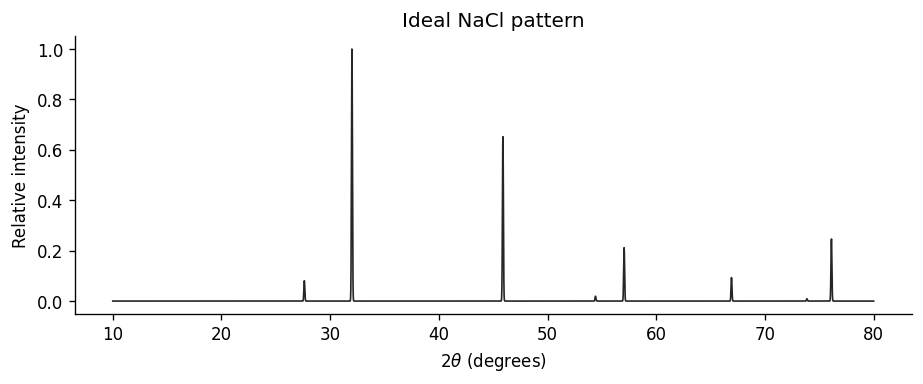

In [3]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(two_theta, ideal, color="0.15", lw=1)
ax.set(xlabel=r"$2\theta$ (degrees)", ylabel="Relative intensity",
       title="Ideal NaCl pattern")
plt.show()

## 2. Load a predefined `.xye` background

`BackgroundPattern.from_file` accepts `.xy`, `.xye`, `.txt`, or
`.dat` samples. The coordinate domain must match the simulation.
Here the third column is a standard uncertainty. The tutorial trace
is explicitly synthetic and illustrates the file interface; measured
traces should retain a meaningful source description. A SHA-256
digest is recorded automatically.

In [4]:
background_trace = BackgroundPattern.from_file(
    ROOT / "demo" / "example_background.xye",
    domain="two_theta",
    third_column="sigma",
    source="synthetic illustrative tutorial trace; not measured data",
)
print("source:", background_trace.source)
print("SHA-256:", background_trace.source_sha256)
print("uncertainty samples:", background_trace.uncertainty.shape)

source: synthetic illustrative tutorial trace; not measured data
SHA-256: da729980251451a815a51a8e2d125ffff44c0d269b2baa9deaf171eba22a9a2b
uncertainty samples: (19,)


## 3. Configure each effect

Each component is a separate immutable object. Fixed values give a
deterministic instrument/sample model; `(low, high)` tuples sample
a value from that range for each call. The `seed` on
`SimulationArtifacts` makes all stochastic choices reproducible.

In [5]:
calibration = CalibrationArtifacts(
    zero_shift=0.08,
    specimen_displacement_mm=-0.10,
    goniometer_radius_mm=200.0,
)

profile = PeakProfileArtifacts(
    model="tch",
    caglioti_u=0.0025,
    caglioti_w=0.0064,
    lorentzian_x=0.008,
    lorentzian_y=0.004,
    crystallite_size_nm=35.0,
    microstrain=0.0007,
    axial_asymmetry=0.008,
)

intensities = IntensityArtifacts(
    peak_jitter=(0.94, 1.06),
    preferred_orientation=PreferredOrientation(
        axis=(0, 0, 1), ratio=0.72, fraction=1.0
    ),
)

background = BackgroundArtifacts(
    constant=0.012,
    amorphous_humps=(
        AmorphousHump(center=25.0, fwhm=12.0, height=0.06),
    ),
    measured=background_trace,
    measured_scale=0.8,
)

spurious_peaks = SpuriousPeakArtifacts(
    count=3,
    intensity=(0.008, 0.020),
    fwhm=(0.12, 0.20),
    eta=(0.2, 0.7),
)

noise = NoiseArtifacts(
    poisson_count_scale=1800.0,
    gaussian_std=0.003,
    correlated_std=0.006,
    correlation_length=0.18,
)

detector = DetectorArtifacts(
    excluded_ranges=((62.0, 63.0),),
    random_mask_probability=0.005,
    saturation_level=0.82,
    quantization_step=0.00625,
)

## 4. Simulate the complete pattern

Effects are applied in a defined pipeline: calibration and
reflection intensities, profile rendering, background and spurious
peaks, noise, then detector response. `normalize_signal=True`
normalizes the crystalline profile before backgrounds are added;
`final_normalize=True` scales the final output for display.

In [6]:
artifacts = SimulationArtifacts(
    calibration=calibration,
    profile=profile,
    intensity=intensities,
    background=background,
    spurious_peaks=spurious_peaks,
    noise=noise,
    detector=detector,
    normalize_signal=True,
    final_normalize=True,
    domain="two_theta",
    seed=2026,
)

artifact_grid, simulated = calculator.pattern(artifacts=artifacts)
simulated = np.asarray(simulated)
np.testing.assert_array_equal(artifact_grid, two_theta)

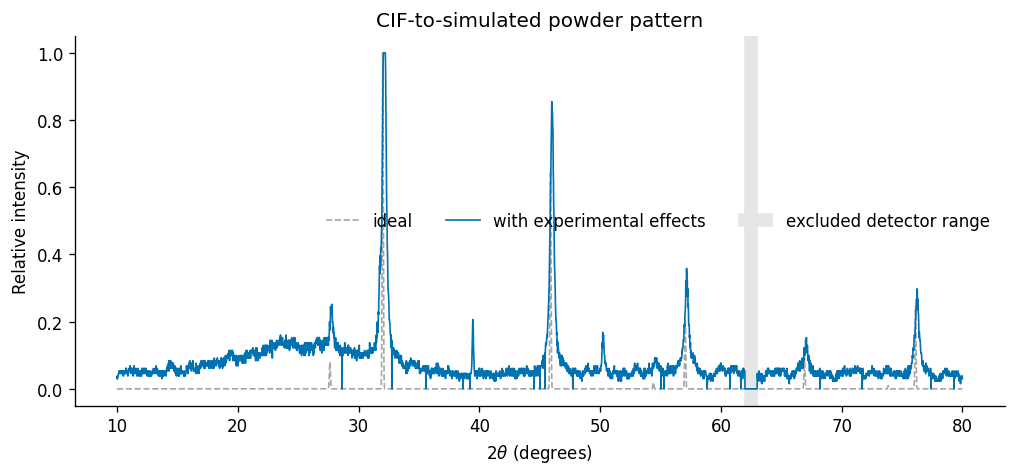

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(two_theta, ideal, color="0.65", ls="--", lw=1, label="ideal")
ax.plot(artifact_grid, simulated, color="#0072B2", lw=1,
        label="with experimental effects")
ax.axvspan(62.0, 63.0, color="0.90", label="excluded detector range")
ax.set(xlabel=r"$2\theta$ (degrees)", ylabel="Relative intensity",
       title="CIF-to-simulated powder pattern")
ax.legend(frameon=False, ncol=3)
plt.show()

## 5. Verify reproducibility and vary components

The same seed reproduces the complete stochastic realization.
Change the seed for another realization, or replace only one
component to isolate its effect. These models are controlled
simulation effects, not a fitted description of a particular
diffractometer.

Exact repeat with seed 2026


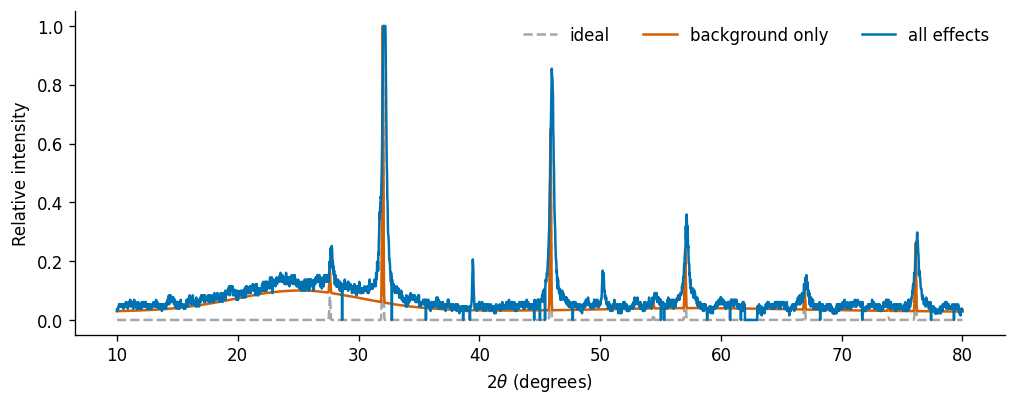

In [8]:
_, repeated = calculator.pattern(artifacts=artifacts)
np.testing.assert_array_equal(simulated, np.asarray(repeated))
print("Exact repeat with seed", artifacts.seed)

background_only = SimulationArtifacts(
    background=background,
    normalize_signal=True,
    final_normalize=True,
    domain="two_theta",
    seed=2026,
)
_, with_background_only = calculator.pattern(artifacts=background_only)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(two_theta, ideal, color="0.65", ls="--", label="ideal")
ax.plot(two_theta, with_background_only, color="#D55E00",
        label="background only")
ax.plot(two_theta, simulated, color="#0072B2", label="all effects")
ax.set(xlabel=r"$2\theta$ (degrees)", ylabel="Relative intensity")
ax.legend(frameon=False, ncol=3)
plt.show()

The returned arrays can now be saved in the format expected by a
downstream workflow. For traceable datasets, retain the CIF,
`SimulationArtifacts` values, random seed, package version, and any
background source/checksum alongside the simulated pattern.